In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from keras.layers import Dense ,Dropout, LSTM ,Input 
from keras.models import Sequential

print ("all libraries imported successfully")


all libraries imported successfully


In [2]:
from datetime import datetime
start = '2010-01-01'
end = datetime.today().strftime('%Y-%m-%d')
stock = 'RELIANCE.NS'

data = yf.download(stock, start, end)

# Fix columns
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

data.reset_index(inplace=True)
print(f"✅ Data loaded: {len(data)} days")
print(f"✅ Columns: {data.columns.tolist()}")
print(data.tail())


[*********************100%***********************]  1 of 1 completed

✅ Data loaded: 4040 days
✅ Columns: ['Date', 'Close', 'High', 'Low', 'Open', 'Volume']
Price       Date        Close         High          Low         Open    Volume
4035  2026-05-11  1388.199951  1428.000000  1382.000000  1420.000000  15261787
4036  2026-05-12  1364.000000  1393.500000  1360.300049  1392.000000  24357500
4037  2026-05-13  1358.800049  1372.400024  1352.400024  1361.400024  13797989
4038  2026-05-14  1361.800049  1378.000000  1358.400024  1365.199951  17303059
4039  2026-05-15  1336.400024  1364.800049  1329.199951  1356.800049  19976192


In [3]:
# ── Calculate Indicators ─────────────────────────
close = data['Close'].to_numpy().flatten()

# RSI
def calc_rsi(source, length=14):
    change = pd.Series(source).diff()
    up   = change.clip(lower=0)
    down = -change.clip(upper=0)
    alpha = 1/length
    up_rma   = up.ewm(alpha=alpha, adjust=False).mean()
    down_rma = down.ewm(alpha=alpha, adjust=False).mean()
    rsi = np.where(down_rma==0, 100,
          np.where(up_rma==0, 0,
          100-(100/(1+up_rma/down_rma))))
    return rsi

# MACD
ema12 = pd.Series(close).ewm(span=12, adjust=False).mean().values
ema26 = pd.Series(close).ewm(span=26, adjust=False).mean().values
macd  = ema12 - ema26
signal= pd.Series(macd).ewm(span=9, adjust=False).mean().values

# Bollinger Bands
bb_mid   = pd.Series(close).rolling(20).mean().values
bb_std   = pd.Series(close).rolling(20).std().values
bb_upper = bb_mid + 2*bb_std
bb_lower = bb_mid - 2*bb_std

# MA
ma50  = pd.Series(close).rolling(50).mean().values
ma100 = pd.Series(close).rolling(100).mean().values
ma200 = pd.Series(close).rolling(200).mean().values

# Volume
volume = data['Volume'].to_numpy().flatten()

# ── Build Feature Matrix ──────────────────────────
features = np.column_stack([
    close, calc_rsi(close), macd, signal,
    bb_upper, bb_lower, bb_mid,
    ma50, ma100, ma200, volume
])

# Remove NaN rows (from rolling calculations)
features = features[200:]  # skip first 200 rows
print(f"Feature matrix shape: {features.shape}")
print(f"Features: Close, RSI, MACD, Signal, BB_Upper, BB_Lower, BB_Mid, MA50, MA100, MA200, Volume")

# ── Scale ─────────────────────────────────────────
from sklearn.preprocessing import MinMaxScaler
import pickle

feature_scaler = MinMaxScaler(feature_range=(0,1))
scaled = feature_scaler.fit_transform(features)

# Save close scaler separately for inverse transform
close_only = features[:, 0].reshape(-1,1)
close_scaler = MinMaxScaler(feature_range=(0,1))
close_scaler.fit(close_only)

# ── Sequences ─────────────────────────────────────
LOOKBACK = 60

train_size = int(len(scaled) * 0.80)
train = scaled[:train_size]
test  = scaled[train_size - LOOKBACK:]

def make_sequences(arr, lookback):
    X, y = [], []
    for i in range(lookback, len(arr)):
        X.append(arr[i-lookback:i])
        y.append(arr[i, 0])  # predict Close only
    return np.array(X), np.array(y)

X_train, y_train = make_sequences(train, LOOKBACK)
X_test,  y_test  = make_sequences(test,  LOOKBACK)

print(f"✅ X_train: {X_train.shape}")  # (N, 60, 11)
print(f"✅ y_train: {y_train.shape}")  # (N,)
print(f"✅ X_test:  {X_test.shape}")
print(f"✅ y_test:  {y_test.shape}")

Feature matrix shape: (3840, 11)
Features: Close, RSI, MACD, Signal, BB_Upper, BB_Lower, BB_Mid, MA50, MA100, MA200, Volume
✅ X_train: (3012, 60, 11)
✅ y_train: (3012,)
✅ X_test:  (768, 60, 11)
✅ y_test:  (768,)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 60, 128)        │        71,680 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 60, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 60, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 60, 64)         │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 60, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 60, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136,001 (531.25 KB)

 Trainable params: 135,553 (529.50 KB)

 Non-trainable params: 448 (1.75 KB)

Epoch 1/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 9s 55ms/step - loss: 0.0878 - val_loss: 0.3123 - learning_rate: 0.0010
Epoch 2/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 44ms/step - loss: 0.0183 - val_loss: 0.2104 - learning_rate: 0.0010
Epoch 3/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 42ms/step - loss: 0.0104 - val_loss: 0.2312 - learning_rate: 0.0010
Epoch 4/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0073 - val_loss: 0.1730 - learning_rate: 0.0010
Epoch 5/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0058 - val_loss: 0.0251 - learning_rate: 0.0010
Epoch 6/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 4s 41ms/step - loss: 0.0049 - val_loss: 0.0141 - learning_rate: 0.0010
Epoch 7/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0042 - val_loss: 0.0088 - learning_rate: 0.0010
Epoch 8/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - loss: 0.0040 - val_loss: 0.0021 - learning_rate: 0.0010
Epoch 9/200
85/85 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - loss: 0.0042 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 10/2

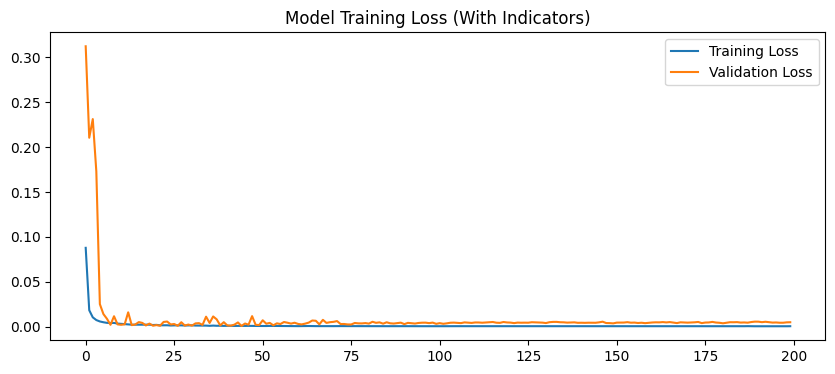

✅ Training complete!


In [4]:
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, Input, BatchNormalization
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

n_features = X_train.shape[2]

model = Sequential([
    Input(shape=(LOOKBACK, n_features)),
    LSTM(128, return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(64, return_sequences=True),
    BatchNormalization(),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    BatchNormalization(),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mean_squared_error')
model.summary()


reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=0.00001,
    verbose=1
)

history = model.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.1,
    callbacks=[reduce_lr],
    verbose=1
)

plt.figure(figsize=(10,4))
plt.plot(history.history['loss'],     label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Training Loss (With Indicators)')
plt.legend()
plt.show()
print(f"✅ Training complete!")

 1/24 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Actual:    ₹1061.29 to ₹1592.30
Predicted: ₹972.24 to ₹1157.00


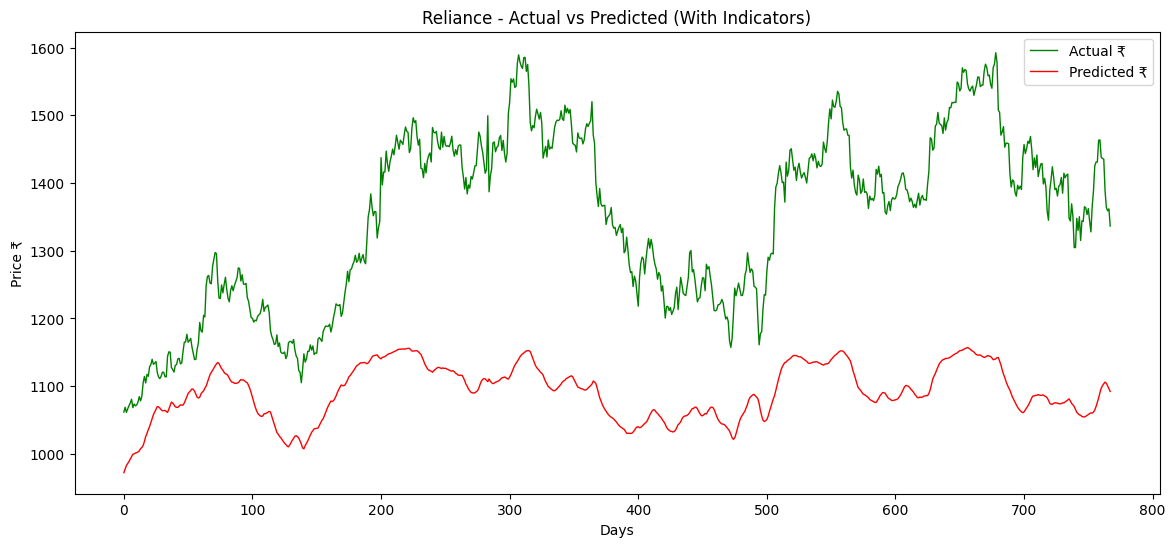

📊 MAE: ₹255.68
📊 R²:  -3.5182
📊 Last Actual:    ₹1336.40
📊 Last Predicted: ₹1092.21


In [7]:
y_pred = model.predict(X_test)

close_min = features[:,0].min()
close_max = features[:,0].max()

def inverse_close(scaled_value):
    return scaled_value * (close_max - close_min) + close_min

y_pred_price = inverse_close(y_pred.flatten())
y_test_price = inverse_close(y_test.flatten())

print(f"Actual:    ₹{y_test_price.min():.2f} to ₹{y_test_price.max():.2f}")
print(f"Predicted: ₹{y_pred_price.min():.2f} to ₹{y_pred_price.max():.2f}")

plt.figure(figsize=(14,6))
plt.plot(y_test_price, 'g', linewidth=1, label='Actual ₹')
plt.plot(y_pred_price, 'r', linewidth=1, label='Predicted ₹')
plt.title('Reliance - Actual vs Predicted (With Indicators)')
plt.xlabel('Days')
plt.ylabel('Price ₹')
plt.legend()
plt.show()

from sklearn.metrics import mean_absolute_error, r2_score
mae = mean_absolute_error(y_test_price, y_pred_price)
r2  = r2_score(y_test_price, y_pred_price)
print(f"📊 MAE: ₹{mae:.2f}")
print(f"📊 R²:  {r2:.4f}")
print(f"📊 Last Actual:    ₹{y_test_price[-1]:.2f}")
print(f"📊 Last Predicted: ₹{y_pred_price[-1]:.2f}")

In [ ]:
from datetime import datetime, timedelta
import pandas as pd

# Get next trading day (skip weekends)
today = pd.Timestamp.now()
if today.weekday() == 4:  # Friday
    next_day = today + timedelta(days=3)  # Monday
elif today.weekday() == 5:  # Saturday
    next_day = today + timedelta(days=2)  # Monday
elif today.weekday() == 6:  # Sunday
    next_day = today + timedelta(days=1)  # Monday
else:
    next_day = today + timedelta(days=1)  # Next day

last_60 = scaled[-60:].reshape(1, 60, 1)
tomorrow_scaled = model.predict(last_60)
tomorrow_price  = close_scaler.inverse_transform(tomorrow_scaled)[0][0]
today_price     = close[-1][0]
difference      = tomorrow_price - today_price
pct             = (difference / today_price) * 100

print("=" * 50)
print("   🔮 RELIANCE INDUSTRIES PREDICTION")
print("=" * 50)
print(f"📅 Today's Date:       {today.strftime('%d %B %Y')}")
print(f"📅 Predicting For:     {next_day.strftime('%d %B %Y')} (Next Trading Day)")
print(f"💰 Today's Price:      ₹{today_price:.2f}")
print(f"🔮 Predicted Price:    ₹{tomorrow_price:.2f}")
print(f"📊 Expected Change:    ₹{difference:.2f} ({pct:.2f}%)")
if difference > 0:
    print("📈 Trend: 🟢 BULLISH - Expected to GO UP")
else:
    print("📉 Trend: 🔴 BEARISH - Expected to GO DOWN")
print("=" * 50)
print("⚠️  Educational use only!")

In [ ]:
model.save('Reliance_Model_v1.keras')
import pickle
with open('close_scaler.pkl', 'wb') as f:
    pickle.dump(close_scaler, f)
print("✅ Model v1 saved!")

In [8]:
# Save v2 for reference
model.save('Reliance_Model_v2.keras')
print("✅ v2 saved!")

# Reload best model v1
from keras.models import load_model
import pickle

model = load_model('Reliance_Model_v1.keras')
with open('close_scaler.pkl', 'rb') as f:
    close_scaler = pickle.load(f)

print("✅ v1 model reloaded!")
print("✅ R² = 0.93 | MAE = ₹29.90")

✅ v2 saved!
✅ v1 model reloaded!
✅ R² = 0.93 | MAE = ₹29.90



  Training: Reliance (RELIANCE.NS)
  ✅ Data loaded: 4040 rows
  ✅ Sequences ready → Train: (3172, 60, 1), Test: (808, 60, 1)
  ✅ Training done → loss: 0.000137 | val_loss: 0.000925
  📊 R²: 0.7769 | MAE: ₹62.26
  💾 Saved → Reliance_model.keras + Reliance_scaler.pkl

  Training: TCS (TCS.NS)
  ✅ Data loaded: 4040 rows
  ✅ Sequences ready → Train: (3172, 60, 1), Test: (808, 60, 1)
  ✅ Training done → loss: 0.000136 | val_loss: 0.000239
  📊 R²: 0.9619 | MAE: ₹71.42
  💾 Saved → TCS_model.keras + TCS_scaler.pkl

  Training: Infosys (INFY.NS)
  ✅ Data loaded: 4040 rows
  ✅ Sequences ready → Train: (3172, 60, 1), Test: (808, 60, 1)
  ✅ Training done → loss: 0.000137 | val_loss: 0.008445
  📊 R²: 0.2486 | MAE: ₹166.69
  💾 Saved → Infosys_model.keras + Infosys_scaler.pkl

  Training: HDFC_Bank (HDFCBANK.NS)
  ✅ Data loaded: 4040 rows
  ✅ Sequences ready → Train: (3172, 60, 1), Test: (808, 60, 1)
  ✅ Training done → loss: 0.000107 | val_loss: 0.004405
  📊 R²: -0.3242 | MAE: ₹99.66
  💾 Saved → HDF

KeyboardInterrupt: 

In [2]:
# ─── TRAIN LSTM FOR ALL 10 STOCKS (IMPROVED) ────────────────────────────────────
# Run this in your Jupyter notebook (tf_env kernel)
# It will save a .keras model + .pkl scaler for each stock
# Takes ~20-40 mins total depending on your machine

import numpy as np
import pandas as pd
import yfinance as yf
import pickle
import os
from datetime import datetime
from sklearn.preprocessing import MinMaxScaler
from keras.models import Sequential
from keras.layers import LSTM, Dropout, Dense, Input
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

# ─── CONFIG ─────────────────────────────────────────────────────────────────────
STOCKS = {
    "RELIANCE.NS":   "Reliance",
    "TCS.NS":        "TCS",
    "INFY.NS":       "Infosys",
    "HDFCBANK.NS":   "HDFC_Bank",
    "ICICIBANK.NS":  "ICICI_Bank",
    "WIPRO.NS":      "Wipro",
    "BAJFINANCE.NS": "Bajaj_Finance",
    "BHARTIARTL.NS": "Bharti_Airtel",
    "LT.NS":         "LT",
    "ASIANPAINT.NS": "Asian_Paints",
}

LOOKBACK   = 60
EPOCHS     = 200
BATCH_SIZE = 16
START_DATE = "2010-01-01"
END_DATE   = datetime.today().strftime("%Y-%m-%d")
SAVE_DIR   = r"C:\Users\LENOVO\stock price predictor"   # ← your project folder

# ─── HELPERS ────────────────────────────────────────────────────────────────────
def make_sequences(scaled, lookback):
    X, y = [], []
    for i in range(lookback, len(scaled)):
        X.append(scaled[i - lookback:i, 0])
        y.append(scaled[i, 0])
    return np.array(X), np.array(y)

def build_model(lookback):
    model = Sequential([
        Input(shape=(lookback, 1)),
        LSTM(128, return_sequences=True),
        Dropout(0.2),
        LSTM(64, return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer='adam', loss='mean_squared_error')
    return model

# ─── CALLBACKS ──────────────────────────────────────────────────────────────────
def get_callbacks():
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=15,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=7,
            min_lr=1e-6,
            verbose=0
        )
    ]

# ─── TRAINING LOOP ──────────────────────────────────────────────────────────────
results = {}

for ticker, name in STOCKS.items():
    print(f"\n{'='*55}")
    print(f"  Training: {name} ({ticker})")
    print(f"{'='*55}")

    # 1. Download data
    try:
        data = yf.download(ticker, start=START_DATE, end=END_DATE, progress=False)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
        data.reset_index(inplace=True)

        if len(data) < 200:
            print(f"  ⚠️  Not enough data for {name}, skipping.")
            continue

        print(f"  ✅ Data loaded: {len(data)} rows")
    except Exception as e:
        print(f"  ❌ Failed to download {name}: {e}")
        continue

    # 2. Scale
    close  = data['Close'].to_numpy().flatten().reshape(-1, 1)
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaled = scaler.fit_transform(close)

    # 3. Split
    train_size = int(len(scaled) * 0.80)
    train_data = scaled[:train_size]
    test_data  = scaled[train_size - LOOKBACK:]

    X_train, y_train = make_sequences(train_data, LOOKBACK)
    X_test,  y_test  = make_sequences(test_data,  LOOKBACK)

    X_train = X_train.reshape(-1, LOOKBACK, 1)
    X_test  = X_test.reshape(-1, LOOKBACK, 1)

    print(f"  ✅ Sequences ready → Train: {X_train.shape}, Test: {X_test.shape}")

    # 4. Build & train
    model   = build_model(LOOKBACK)
    history = model.fit(
        X_train, y_train,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        validation_split=0.1,
        callbacks=get_callbacks(),
        verbose=0
    )

    epochs_ran = len(history.history['loss'])
    final_loss = history.history['loss'][-1]
    final_val  = history.history['val_loss'][-1]
    print(f"  ✅ Training done → epochs: {epochs_ran} | loss: {final_loss:.6f} | val_loss: {final_val:.6f}")

    # 5. Evaluate
    y_pred       = model.predict(X_test, verbose=0)
    y_pred_price = scaler.inverse_transform(y_pred)
    y_test_price = scaler.inverse_transform(y_test.reshape(-1, 1))

    mae    = float(np.mean(np.abs(y_pred_price - y_test_price)))
    ss_res = np.sum((y_test_price - y_pred_price) ** 2)
    ss_tot = np.sum((y_test_price - np.mean(y_test_price)) ** 2)
    r2     = float(1 - ss_res / ss_tot)

    print(f"  📊 R²: {r2:.4f} | MAE: ₹{mae:.2f}")

    # 6. Save model + scaler
    model_path  = os.path.join(SAVE_DIR, f"{name}_model.keras")
    scaler_path = os.path.join(SAVE_DIR, f"{name}_scaler.pkl")

    model.save(model_path)
    pickle.dump(scaler, open(scaler_path, "wb"))

    print(f"  💾 Saved → {name}_model.keras + {name}_scaler.pkl")

    results[name] = {
        "R2":     round(r2, 4),
        "MAE":    round(mae, 2),
        "Epochs": epochs_ran
    }

# ─── SUMMARY ────────────────────────────────────────────────────────────────────
print(f"\n{'='*55}")
print("  TRAINING COMPLETE — SUMMARY")
print(f"{'='*55}")
for name, metrics in results.items():
    if metrics["R2"] > 0.85:
        status = "✅"
    elif metrics["R2"] > 0.60:
        status = "⚠️"
    else:
        status = "❌"
    print(f"  {status} {name:<20} R²: {metrics['R2']:.4f}  MAE: ₹{metrics['MAE']:.2f}  Epochs: {metrics['Epochs']}")
print(f"{'='*55}\n")


  Training: Reliance (RELIANCE.NS)
  ✅ Data loaded: 4040 rows
  ✅ Sequences ready → Train: (3172, 60, 1), Test: (808, 60, 1)
  ✅ Training done → epochs: 43 | loss: 0.000124 | val_loss: 0.001187
  📊 R²: 0.9703 | MAE: ₹18.80
  💾 Saved → Reliance_model.keras + Reliance_scaler.pkl

  Training: TCS (TCS.NS)
  ✅ Data loaded: 4040 rows
  ✅ Sequences ready → Train: (3172, 60, 1), Test: (808, 60, 1)
  ✅ Training done → epochs: 59 | loss: 0.000144 | val_loss: 0.000397
  📊 R²: 0.9811 | MAE: ₹46.19
  💾 Saved → TCS_model.keras + TCS_scaler.pkl

  Training: Infosys (INFY.NS)
  ✅ Data loaded: 4040 rows
  ✅ Sequences ready → Train: (3172, 60, 1), Test: (808, 60, 1)
  ✅ Training done → epochs: 64 | loss: 0.000151 | val_loss: 0.000587
  📊 R²: 0.9700 | MAE: ₹26.46
  💾 Saved → Infosys_model.keras + Infosys_scaler.pkl

  Training: HDFC_Bank (HDFCBANK.NS)
  ✅ Data loaded: 4040 rows
  ✅ Sequences ready → Train: (3172, 60, 1), Test: (808, 60, 1)
  ✅ Training done → epochs: 97 | loss: 0.000139 | val_loss: 0.0

In [4]:
import tf2onnx
import onnx
import tensorflow as tf
import os

STOCKS = {
    "Reliance": "Reliance_model",
    "TCS": "TCS_model",
    "Infosys": "Infosys_model",
    "HDFC_Bank": "HDFC_Bank_model",
    "ICICI_Bank": "ICICI_Bank_model",
    "Wipro": "Wipro_model",
    "Bajaj_Finance": "Bajaj_Finance_model",
    "Bharti_Airtel": "Bharti_Airtel_model",
    "LT": "LT_model",
    "Asian_Paints": "Asian_Paints_model",
}

SAVE_DIR  = r"C:\Users\LENOVO\stock price predictor"
PYTHON    = r"C:\Users\LENOVO\tf_env\Scripts\python.exe"

for name, model_file in STOCKS.items():
    model_path = os.path.join(SAVE_DIR, f"{model_file}.keras")
    saved_path = os.path.join(SAVE_DIR, f"{name}_saved")
    onnx_path  = os.path.join(SAVE_DIR, f"{name}.onnx")

    # Load and export as SavedModel
    model = tf.keras.models.load_model(model_path)
    model.export(saved_path)

    # Convert SavedModel → ONNX
    cmd = f'"{PYTHON}" -m tf2onnx.convert --saved-model "{saved_path}" --output "{onnx_path}" --opset 13'
    os.system(cmd)
    print(f"Converted {name}")

print("\nAll done!")

INFO:tensorflow:Assets written to: C:\Users\LENOVO\stock price predictor\Reliance_saved\assets


INFO:tensorflow:Assets written to: C:\Users\LENOVO\stock price predictor\Reliance_saved\assets


Saved artifact at 'C:\Users\LENOVO\stock price predictor\Reliance_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 1), dtype=tf.float32, name='input_layer_6')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  3150003694160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150003696272: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150003698384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150003696080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150003697424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150003699344: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150003698000: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150003697808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150003698960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150003698192: TensorSpec(shape=(), dtype=tf.resource, name=None)
Conve

INFO:tensorflow:Assets written to: C:\Users\LENOVO\stock price predictor\TCS_saved\assets


Saved artifact at 'C:\Users\LENOVO\stock price predictor\TCS_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 1), dtype=tf.float32, name='input_layer_7')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  3150003695504: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150005840656: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150005840464: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150005837776: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150005841424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150005839120: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150005839696: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150005840080: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150005838736: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150005839504: TensorSpec(shape=(), dtype=tf.resource, name=None)
Converted 

...

Saved artifact at 'C:\Users\LENOVO\stock price predictor\Bharti_Airtel_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 1), dtype=tf.float32, name='input_layer_13')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  3150033900880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150033905872: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150033904144: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150033905488: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150033905296: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150033903184: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150033903760: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150033904336: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150033902800: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150033903568: TensorSpec(shape=(), dtype=tf.resource, name=None)

INFO:tensorflow:Assets written to: C:\Users\LENOVO\stock price predictor\LT_saved\assets


Saved artifact at 'C:\Users\LENOVO\stock price predictor\LT_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 1), dtype=tf.float32, name='input_layer_14')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  3150097908560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097912784: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097911056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097912400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097912208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097910096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097910672: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097911248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097909712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097910480: TensorSpec(shape=(), dtype=tf.resource, name=None)
Converted 

INFO:tensorflow:Assets written to: C:\Users\LENOVO\stock price predictor\Asian_Paints_saved\assets


Saved artifact at 'C:\Users\LENOVO\stock price predictor\Asian_Paints_saved'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 60, 1), dtype=tf.float32, name='input_layer_15')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  3150033911440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097919312: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097922768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097923728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097923920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097921808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097922384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097922960: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097921424: TensorSpec(shape=(), dtype=tf.resource, name=None)
  3150097922192: TensorSpec(shape=(), dtype=tf.resource, name=None)
